**Part 2a — Advanced Features & MCP** (3 of 4)
[Part 1a — API Fundamentals](part1a_fndmntl_api.ipynb) | [Part 1b — Prompting, Tools & RAG](part1b_fndmntl_prompting_tools_rag.ipynb) | **[Part 2a — Advanced Features & MCP](part2a_advncd_features_mcp.ipynb)** | [Part 2b — MCP Transport, Claude Code & Agents](part2b_advncd_mcp_claude_code_agents.ipynb)

## 40.1.9) Advanced Claude Features

### 40.1.9  a) Extended Thinking in Claude
- If extended thinking is enabled - then you will be charged for the thinking tokens
- First try to improve your prompt, run evals - and if it is still not improving then switch on extended thinking
- With extended thinking enabled .. in the response message block - we will get a **"Thinking Block also"** - along with the text block.
- In the thinking block - a **signature** is recieved. This is the signature id of the thinking text - as claude wants to make sure that this is not updated at all. So when the message chain continues - the previous thinking signarure id is sent - and the exact thinking message is extracted from claude server and then the conversation continues --- i.e. even if you change the thinking text at your end - that will not be used in the conversation -- the text stored in claude server will be used. 
- **Redacted thinking :**
    - In some cases - e.g. if claude does not want to share thinking data to avoid competitors from using their thinking data to train their models. 
    - Redacted block is a fully thinking block - but is encrypted. So in this case - only the id is send back to server .. and if the server sends the id back to claude - then claude will pull the real thinking from its server and continues the conversation. 


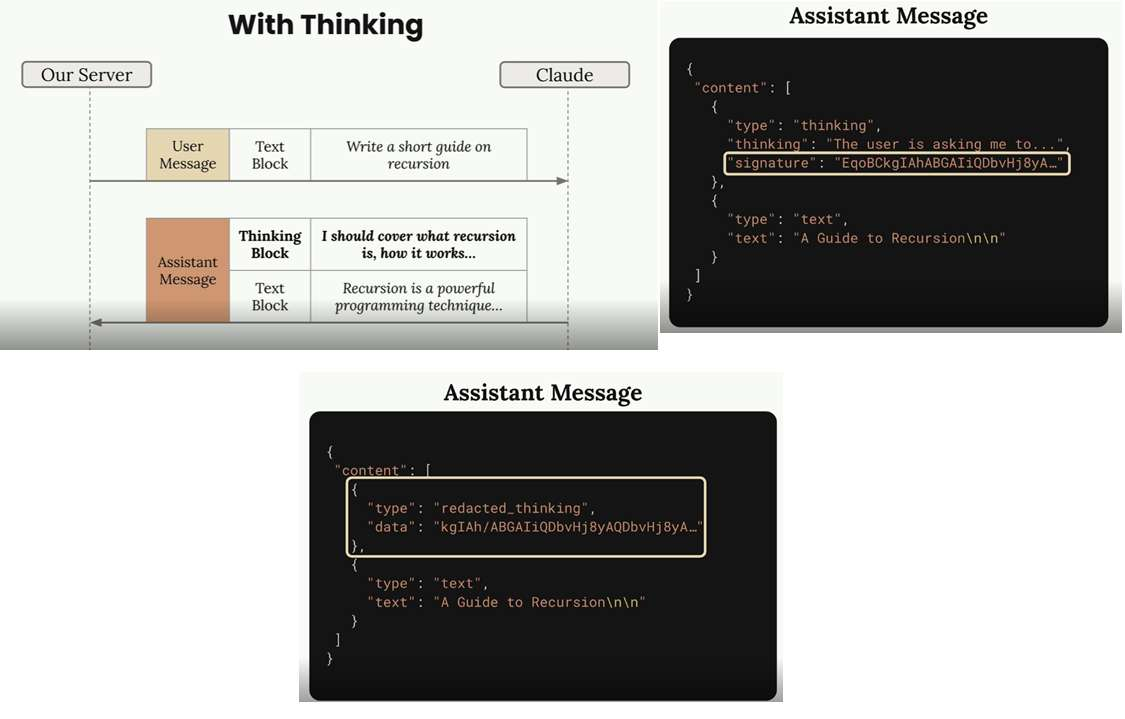

In [31]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/claude_thinking.png', embed=True))

- In the chat() function .. a parameter thinking= True/false needs to be added
- thinking_budget needs to be added. minimum is 1024
- max_tokens should be more than thinking budget.
- code present in "claude_thinking_utils.py"
- How to handle redacted thinking block and halding signature id of normal thinking block is not covered - its ok - can be explored later during implementation if needed. 

In [2]:
from utils.claude_thinking_utils import *

messages = []

add_user_message(messages, "Write a one paragraph guide to recursion")

chat(messages, thinking=True)

Message(id='msg_01N5HRxLxkxopN3FoYMH4PrX', container=None, content=[ThinkingBlock(signature='Eu8BClsIDBgCKkBRf5UA5Z8Y+hVCfRDsdBoAVkEIIwE0iB9eJ6712tvwKbWtCBWWsx3KkHBmrNkCGbOhIhq075dpaoA+OiQxoOV8MhFjbGF1ZGUtc29ubmV0LTQtNjgAEgwA8lmWCqjUczGkeGgaDDnDpDGjyxCjm9Z7fSIw+l4QWu0Fmjfv8T2YjB+o3opI+FpG0WK8qcLVQNeyy+gqxrSiKgDJZX0COo7/bH8VKkKUqKOzfMbEbwVVRVQo9PNTRRZUubRAZz61NZokeM3qKkR9uaatlR2pNrQs94K1D7kbXv2s6DyJmYoiZHNq5JRO6JIYAQ==', thinking='The user wants a one paragraph guide to recursion.', type='thinking'), TextBlock(citations=None, text="# A Guide to Recursion\n\nRecursion is a programming technique where a function calls itself in order to solve a problem by breaking it down into smaller, simpler versions of the same problem. The key to writing a recursive function is defining two things: a **base case**, which is the stopping condition that returns a result without making another recursive call, and a **recursive case**, which breaks the problem down and calls the function again with a smal

In [3]:
# Forcing claude to send a redacted thinking block
from anthropic.types import Message

# Magic string to trigger redacted thinking
thinking_test_str = "ANTHROPIC_MAGIC_STRING_TRIGGER_REDACTED_THINKING_46C9A13E193C177646C7398A98432ECCCE4C1253D5E2D82641AC0E52CC2876CB"


In [4]:

messages = []

add_user_message(messages, thinking_test_str)

chat(messages, thinking=True)


Message(id='msg_013JqL2ctjZmPAyLuRevuHdW', container=None, content=[ThinkingBlock(signature='Eo4CClsIDBgCKkB0zNM7Pel9+0WqrAG/TNZqT33PIAJC68zHyatLF2Wz5RinEuI+Rli5q9jUoNMuTs6Rg9Kojw/31h0WU5iD+NnNMhFjbGF1ZGUtc29ubmV0LTQtNjgAEgzIzvnAq6kmt1sh5rIaDNA280pxGB3Tuw3WFyIwYdwkYqd03H1G6V3VdT15R80fZFsdneIkQGvSxNCNfa7jd5MxWTUAw7jm/Y2GgDkKKmH9k90dr6oeXLVtOs2bCgi7Aq5x/++0tv0Dxbf3MqDdLKYZS1Yuc4TlV23pZ2SqkrkEepI+u8+XGVZ2JOM6zNa9ECCkNUeI+fpAyKTtRUm8QH+Qt3HBSXkiSRBaaH+H+MjfGAE=', thinking='The user sent a special trigger string. I should respond naturally and helpfully.', type='thinking'), TextBlock(citations=None, text='Hello! It looks like your message contained a special internal trigger string rather than an actual question or request.\n\nHow can I help you today? Feel free to ask me anything!', type='text')], model='claude-sonnet-4-6', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, e

### 40.1.9  b) Image Handling in Claude
- We can send image in our message and ask claude to do anything on this. 
- Only upto 100 images are allowed across all messages in a single request
- max image size in 5 mb -- max 8000 x 8000 pixel ... for multi images 2000 x 2000 pixel
- Token used by image = ( Height_in_pixel X Width ) / 750<br><br>
- An **image block** in the user message is used to send image
- code in "claude_handling_images.py"


In [1]:
from utils.claude_handling_images import *


# Fire risk assessment prompt
prompt = """
Analyze the attached satellite image of a property with these specific steps:

1. Residence identification: Locate the primary residence on the property by looking for:
   - The largest roofed structure 
   - Typical residential features (driveway connection, regular geometry)
   - Distinction from other structures (garages, sheds, pools)
   Describe the residence's location relative to property boundaries and other features.

2. Tree overhang analysis: Examine all trees near the primary residence:
   - Identify any trees whose canopy extends directly over any portion of the roof
   - Estimate the percentage of roof covered by overhanging branches (0-25%, 25-50%, 50-75%, 75-100%)
   - Note particularly dense areas of overhang

3. Fire risk assessment: For any overhanging trees, evaluate:
   - Potential wildfire vulnerability (ember catch points, continuous fuel paths to structure)
   - Proximity to chimneys, vents, or other roof openings if visible
   - Areas where branches create a "bridge" between wildland vegetation and the structure
   
4. Defensible space identification: Assess the property's overall vegetative structure:
   - Identify if trees connect to form a continuous canopy over or near the home
   - Note any obvious fuel ladders (vegetation that can carry fire from ground to tree to roof)

5. Fire risk rating: Based on your analysis, assign a Fire Risk Rating from 1-4:
   - Rating 1 (Low Risk): No tree branches overhanging the roof, good defensible space around the structure
   - Rating 2 (Moderate Risk): Minimal overhang (<25% of roof), some separation between tree canopies
   - Rating 3 (High Risk): Significant overhang (25-50% of roof), connected tree canopies, multiple points of vulnerability
   - Rating 4 (Severe Risk): Extensive overhang (>50% of roof), dense vegetation against structure, numerous ember catch points, limited defensible space

For each item above (1-5), write one sentence summarizing your findings, with your final response being the numeric Fire Risk Rating (1-4) with a brief justification.
"""

In [4]:
# Read image data, feed into Claude
import base64

with open(r"Input_and_Output\claude_images_testing\prop7.png", "rb") as f:
    image_bytes = base64.standard_b64encode(f.read()).decode('utf-8')

messages = []

add_user_message(messages, [
    {
        "type": "image",
        "source": {
            "type": "base64",
            "media_type": "image/png",
            "data": image_bytes
        }
    },
    {
        "type": "text",
        "text": prompt
    }
])

chat(messages)

Message(id='msg_01XucbE2Z522wYFbWApjNdTo', container=None, content=[TextBlock(citations=None, text='## Satellite Image Fire Risk Analysis\n\n**1. Residence Identification:**\nThe primary residence is a multi-section structure with a gray/tan roof located in the center-lower portion of the image, featuring an irregular L-shaped or T-shaped footprint with what appears to be a connected garage or secondary wing, situated well within a densely wooded lot with no clearly visible open driveway approach from this vantage point.\n\n**2. Tree Overhang Analysis:**\nMultiple large trees with broad canopies directly overhang the roof, particularly on the left/northwest side and lower/southern portions of the structure, with an estimated **50-75% of the total roof surface** covered or immediately shadowed by overhanging branches, with particularly dense overhang visible on the western wing.\n\n**3. Fire Risk Assessment:**\nThe overhanging branches create multiple direct fuel bridges from the surrou

### 40.1.9  c) PDF Handling in Claude
- Very similar to image handling
- Claude will read text and images, charts, tables from pdf<br><br>
- A **document block** in the user message is used to send pdf
- same code as in "claude_handling_images.py"


In [8]:
from utils.claude_handling_images import *
import base64

with open(r"Input_and_Output\claude_pdf_testing\earth.pdf", "rb") as f:
    file_bytes = base64.standard_b64encode(f.read()).decode("utf-8")

messages = []

add_user_message(
    messages,
    [
        {
            "type": "document",
            "source": {
                "type": "base64",
                "media_type": "application/pdf",
                "data": file_bytes,
            },
        },
        {"type": "text", "text": "Summarize the document in one sentence"},
    ],
)

chat(messages)

Message(id='msg_019zaxRg7EmBWc5yJcruubwb', container=None, content=[TextBlock(citations=None, text='Earth is the third planet from the Sun, the only known planet to harbor life, characterized by its liquid water oceans, dynamic atmosphere, tectonic activity, and a single natural satellite (the Moon), having formed approximately 4.5 billion years ago.', type='text')], model='claude-sonnet-4-6', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='global', input_tokens=9626, output_tokens=57, server_tool_use=None, service_tier='standard'))

### 40.1.9  d) Citations in Claude
- Continuing on the PDF example for citations
<br><br>
- A **citations** parameter has to be enabled.
- The response for below will be much more complicated now -- it will have text block and citation blocks


In [9]:
from utils.claude_handling_images import *

with open(r"Input_and_Output\claude_pdf_testing\earth.pdf", "rb") as f:
    file_bytes = base64.standard_b64encode(f.read()).decode("utf-8")

messages = []

add_user_message(
    messages,
    [
        {
            "type": "document",
            "source": {
                "type": "base64",
                "media_type": "application/pdf",
                "data": file_bytes,
            },
            "title":"earth.pdf",
            "citations" : {"enabled": True}
        },
        {"type": "text", "text": "How were Earth's atmosphere and oceans were formed?"},
    ],
)
chat(messages)

Message(id='msg_01UNkqAqynR9hbcLMoWvgEoj', container=None, content=[TextBlock(citations=None, text='Based on the document, ', type='text'), TextBlock(citations=[CitationPageLocation(cited_text="[42]\r\nEarth's atmosphere and oceans were formed by volcanic activity and outgassing.\r\n[43] Water vapor from\r\nthese sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets,\r\nand comets.\r\n", document_index=0, document_title='earth.pdf', end_page_number=5, file_id=None, start_page_number=4, type='page_location')], text="Earth's atmosphere and oceans were formed by volcanic activity and outgassing. Water vapor from these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets, and comets.", type='text'), TextBlock(citations=None, text='\n\nAdditionally, ', type='text'), TextBlock(citations=[CitationPageLocation(cited_text='[45]\r\nIn this\r\nmodel, atmospheric greenhouse gases kept the oceans from freezing when the newly

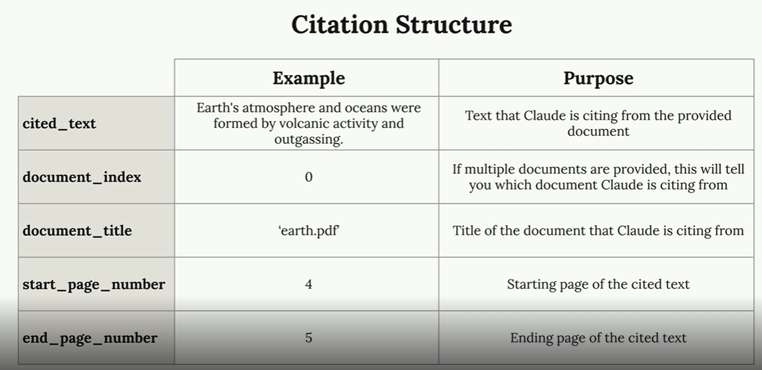

In [41]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/claude_citation.png', embed=True))

- Take the above output - go to claude chat interface .. ask it to render it into a nicely formatted document and give popup to represent all the different citation. 
- It generates the response below - in which if you hover over the citation you can see the details
- You can then ask claude to give you code to generate this kind of markdown format -- and that can be included in your application if needed. 


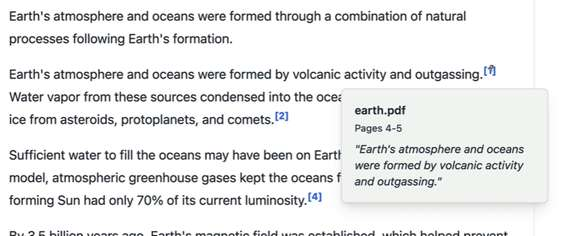

In [43]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/claude_citation_v2.png', embed=True))

- Citations can also be given for text or any other document type - example below. It need not be a pdf only.
- The article text was very large -- so have it in "claude_citation_testing.py" ... It is basically the content of pdf copied in this variable .. just for testing
- In this -- we will get citation char location .. instead of citation text location ... so again this needs to be handled separately in the server side code in your applciation. 
- You can cite from plain text , pdf document , web search .. and other types of documents also

In [11]:
from utils.claude_citation_testing import *
article_text = article_text_v1

In [12]:
from utils.claude_handling_images import *

with open(r"Input_and_Output\claude_pdf_testing\earth.pdf", "rb") as f:
    file_bytes = base64.standard_b64encode(f.read()).decode("utf-8")

messages = []

add_user_message(
    messages,
    [
        {
            "type": "document",
            "source": {
                "type": "text", ### This is Changed
                "media_type": "text/plain", ### This is Changed
                "data": article_text, ### This is Changed
            },
            "title": "Earth Article",
            "citations": {"enabled": True},
        },
        {
            "type": "text",
            "text": "How were Earth's atmosphere and oceans were formed?",
        },
    ],
)

chat(messages)

Message(id='msg_01VMA2xDAVLxwDWa5VqE6N8S', container=None, content=[TextBlock(citations=None, text="Based on the document, here is how Earth's atmosphere and oceans were formed:\n\n", type='text'), TextBlock(citations=[CitationCharLocation(cited_text="[42]\nAfter formation\nEarth's atmosphere and oceans were formed by volcanic activity and outgassing.\n[43] Water vapor from\nthese sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets,\nand comets.\n", document_index=0, document_title='Earth Article', end_char_index=10109, file_id=None, start_char_index=9877, type='char_location')], text="Earth's atmosphere and oceans were formed by volcanic activity and outgassing. Water vapor from these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets, and comets.", type='text'), TextBlock(citations=None, text='\n\nAdditionally, ', type='text'), TextBlock(citations=[CitationCharLocation(cited_text='[44] Sufficient water to 

### 40.1.9  e) Prompt Caching
- Before the LLM can start generating the next token prediction -- claude internally does a lot of pre-processing : 
    - Tokenize the prompt
    - Create embedding
    - Update embedding based on surrounding text
- Only after the above - the embedding is send to LLM for final inferencing
- So with prompt caching -- for the previous messages -- we want to save all this preprocessed data -- so that it is not required to be re-processes and can be sent to the model directly -- saving time and money<br><br>
- Prompt caching increases speed - and descreases cost<br><br>
- The messages saved in cache only stays there for 1 hour. Prompt caching is ephemeral.
- Minimum 1024 tokens is needed to enable caching.
- Caching is not enabled by default - it has to be enabled explicitly
- A cache breakpoint has to be added to cache the message --- and later when the same message chain is sent to claude it will use the cached results ... however - if even a comma changes in the previous message -- then claude will reprocess everything. <br><br>
- If there is a user message --> then assisstant message --> then tool call --> then tool output --> then assistance message --> then user message with cache ...... In this case everthing above the last user message with cache will be cached <br><br>
- Cache breakpoint can be added separately for each type of message blocks : Text block , Image block, Tool use block, Tool result block, System prompts , Tool schema<br><br>
- Caching is enabled for tools and system prompt very often as they rarely change. <br><br>
- Overall : We can apply cache breakpoints to **1. Message blocks** and **2. System prompt**<br><br>
- Whenever you have Tool definitions, System prompt, messages -- Claude arranges them in this order : Tool_definition --> System prompt --> messages
    - So first tool definitions .. then system prompt .. then messages
    - So if you put your cache breakpoint on the very last tool -- every tool definition before that gets cached automatically
    - If you put your cache breakpoint on system prompt ... then every tool definition and the system prompt gets cached.<br><br>
- **We can add upto 4 cache breakpoints -- per request**
    - This is per request ... but in the subsequent request you can have 4 more breakpoints
    - Practical would be to add caching after tool call output ( as they can be lengthy ) ... and the breakpoint will keep advancing forever -- no problem
    - When you have cached till message 100 .. and send message 101 ( with caching ) ... then claude will read from cache till message 100 -- so you will reach from cache at cheap cost .. then add message 101 as cache write .. only for message 101 
    - You can keep doing this for ever .. but it is not recommended to cache converstation ... its recommended to only cache tools and system prompts .. and files like Claude.md.



### Understanding Prompt Caching + Compaction (2 Breakpoints)

#### Structure
- you keep breakpoint 1 after system prompt ... so that covers tools definition + sytem
- Breakpoint 2 is which you keep moving as the conversation progresses -- from user message --> assistant --> tool call --> tool output --> assistant ... and so on .... In a very aggresive approach you move this breakpoint 2 after every conversation turn... so it will look something like : 

```text
[Tools] 
[System Prompt]          ← Breakpoint 1
--------------------------------------
[User + Assistant + Tool thread]  ← Breakpoint 2 (moving forward over time)
```
<br><br>
- The below is a compressed view of the above

```text
[Tools + System]        ← cached (Breakpoint 1)
[Conversation full]     ← cached incrementally (Breakpoint 2)
```

---

#### After Context Compaction
- Now lets say conversation became very long and you had to compact the convesation of user message --> assistant --> tool call --> tool output --> assistant ... then it will look like following. 

```text
[Tools + System]        ← unchanged → cache HIT ✅
[Compacted Conversation] ← changed → cache MISS ❌ (recomputed)
```

---

#### Key Rules

* Cache works on **exact token match (prefix-based)**
* **System + Tools remain cached** if unchanged
* **Conversation cache breaks** after compaction (new tokens)
* Only the **changed portion is re-cached**, not everything


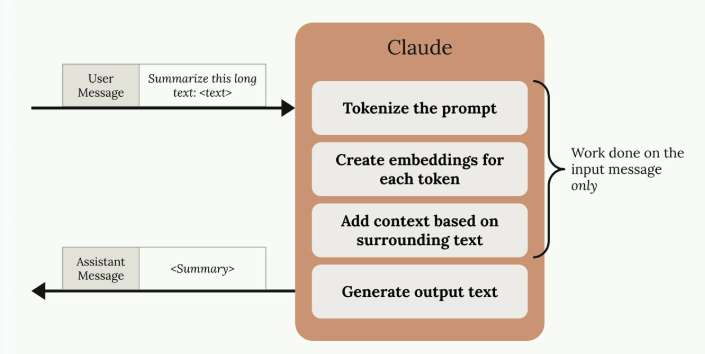

In [13]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/prompt_caching_v1.png', embed=True))

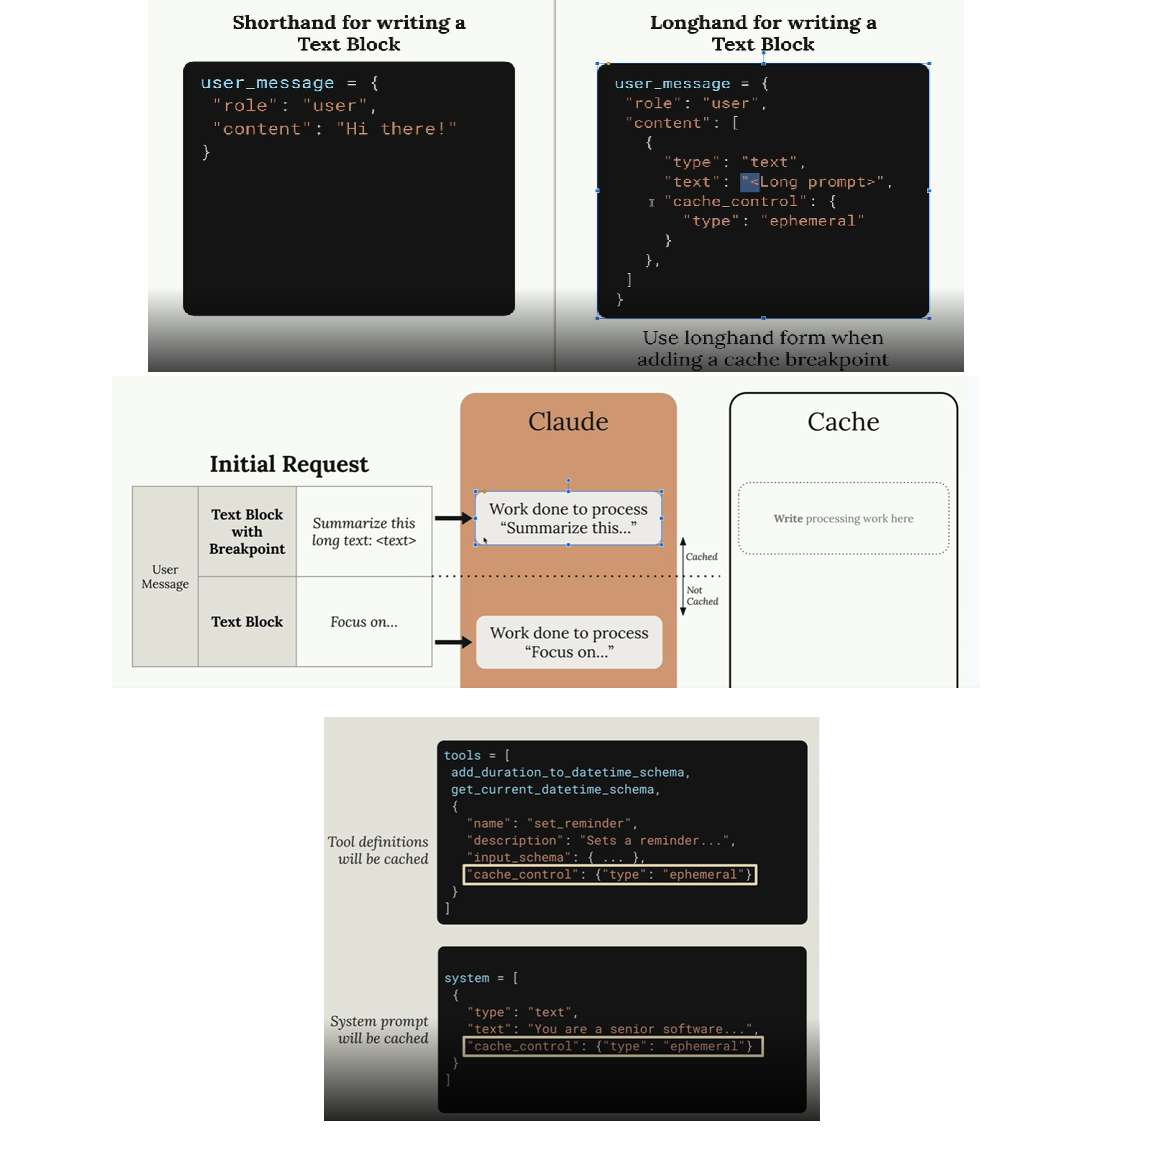

In [16]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/prompt_caching_v2.png', embed=True))

### Prompt Caching - code
- In this code we will cache : 
    - Tool definition ( or tool schema ) : Strictly speaking this is not needed in practice .. just cache system prompt
    - System prompt
- The initial prompt is ~6k token ... and tool schema is ~1.7k token .. so we will see how much prompt caching is saving us also very clearly.
- code in "prompt_caching"
    - Look in chat() definition to see how caching was enabled for tool and system prompt

In [2]:
from utils.prompt_caching import *

tools = [
    db_query_schema,
    add_duration_to_datetime_schema,
    set_reminder_schema,
    get_current_datetime_schema,
]
messages = []

add_user_message(messages, "what's 1+1?")

chat(messages,tools=tools)

Message(id='msg_01GLWUgELTpoNjN9DujZMqJy', container=None, content=[TextBlock(citations=None, text='1 + 1 = 2', type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=1773), cache_creation_input_tokens=1773, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=334, output_tokens=13, server_tool_use=None, service_tier='standard'))

- Notice that we have cache_creation_input_tokens=1773 in the above ... so the tools were added to the cache
- Next when we run the same again --- the tool definition should ideally get read from cache ... and we see that there is cache_read_input_tokens=1773 ... which means tools were read from cache. 

In [3]:
messages = []

add_user_message(messages, "what's 1+1?")

chat(messages,tools=tools)

Message(id='msg_01Vh1gfTgtpSgqenbZgsZquf', container=None, content=[TextBlock(citations=None, text='1 + 1 = 2', type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=1773, inference_geo='not_available', input_tokens=334, output_tokens=13, server_tool_use=None, service_tier='standard'))

- Next we add the 6000 token system prompt.. and we see a cache input entry. 

In [4]:
messages = []

add_user_message(messages, "what's 1+1?")

chat(messages,tools=tools, system = code_prompt)

Message(id='msg_01VGa81GFEhvzq1gKNfRBPc1', container=None, content=[TextBlock(citations=None, text='1 + 1 = 2', type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=6332), cache_creation_input_tokens=6332, cache_read_input_tokens=1773, inference_geo='not_available', input_tokens=329, output_tokens=13, server_tool_use=None, service_tier='standard'))

- Next we rerun the same and we see that the system prompt is read from cache

In [5]:
messages = []

add_user_message(messages, "what's 1+1?")

chat(messages,tools=tools, system = code_prompt)

Message(id='msg_01FF67VmF3rYqLmxHNjyRovi', container=None, content=[TextBlock(citations=None, text='1 + 1 = 2', type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=8105, inference_geo='not_available', input_tokens=329, output_tokens=13, server_tool_use=None, service_tier='standard'))

## 40.1.10) Code Execution & Files API

### 40.1.10  a) Code Execution in Claude

### 40.1.10  b) Files API in Claude
- **Files API**
    - Using the Files API -- we can upload a document to claude -- and get a file_id ... then in subsequent prompt we can just refer to the file id and claude will automatically pull it from the uploaded file ... no need to reupload the file in every prompt
    - This can be used to provide image, pdf or any other file to claude<br><br>
- **Code Execution**
    - Code exection is a server based tool. 
    - We dont have to provide any function definition or implementation for this tool. All we have to do is to provide a pre-defined tool schema -- like we did for web search tool
    - When this tool is provided - Claude can decide to execute some python code or any other code inside a sandbox / docker container - if it is needed to respond to the user request
    - This docker container does not have internet access ... so claude uses the file_ids to move file in and out of this container
    - So the first step is that we should use files api to upload the file ... get file id ... then along with the user message .. we also send "Container Upload Block" to upload the file in the container .. and message to claude to request for analysis of that data .... claude will then only be able to perform the needed analysis using python code. 
    - code in "code_execution.py"
        - There is an upload function -- which will upload a file .. based on its type
        - There is a list_files function -- which will list out all the different files we have uploaded to claude
        - there is delte_file function --- to delete uploaded file
        - there is download_file function -- to download file
        - thre is get_metadata function -- to get information about the file such as size, etc.


In [2]:
from utils.code_execution import *

In [3]:
file_metadata = upload(r"Input_and_Output\code_execution_testing\streaming.csv")
file_metadata

FileMetadata(id='file_011CaHGexNPQtu1bh1rPkgTd', created_at=datetime.datetime(2026, 4, 21, 16, 57, 54, 786000, tzinfo=datetime.timezone.utc), filename='streaming.csv', mime_type='text/csv', size_bytes=25733, type='file', downloadable=False, scope=None)

In [4]:
messages = []

add_user_message(
    messages,
    [
        {
            "type": "text",
            "text": """
Run a detailed analysis to determine major drivers of churn.
Your final output should include at least one detailed plot summarizing your findings.

Critical note: Every time you execute code, you're starting with a completely clean slate. 
No variables or library imports from previous executions exist. You need to redeclare/reimport all variables/libraries.
            """,
        },
        {"type": "container_upload", "file_id": file_metadata.id},
    ],
)

chat(messages, tools=[{"type": "code_execution_20250825", "name": "code_execution"}])

Message(id='msg_019ZJw1159bxA2kyAVY9QfM3', container=Container(id='container_011CaHGgb6Wwot7foZG3HMEt', expires_at=datetime.datetime(2026, 4, 21, 18, 2, 23, 337063, tzinfo=TzInfo(UTC))), content=[TextBlock(citations=None, text="I'll analyze the streaming.csv file to determine the major drivers of churn. Let me start by exploring the data.", type='text'), ServerToolUseBlock(id='srvtoolu_01V4i8X6RDB3dfYvqbgw849S', caller=None, input={'command': 'cd $INPUT_DIR && head -20 streaming.csv'}, name='bash_code_execution', type='server_tool_use'), BashCodeExecutionToolResultBlock(content=BashCodeExecutionResultBlock(content=[], return_code=0, stderr='', stdout='UserID,SubscriptionTier,TotalViewingHoursLastMonth,TopGenre,BingeWatchingSessionsLastMonth,NumberOfUniqueTitlesWatchedLastMonth,AverageSessionDurationMinutes,CustomerServiceInteractionsLastYear,MonthlyCost,Churned\nUSER_00001,Basic,47.9,Comedy,5,15,32.6,3,7.99,0\nUSER_00002,Premium,41.4,Drama,5,9,45.7,3,17.99,0\nUSER_00003,Standard,33.6,A

- In the above code execution call -- we get all the code that claude wrote -- all the print statement and output that it got -- and some final analysis also
- First is a text block 
- Then there is a ServerToolUse block --- this will have code that claude runs inside the container
- Then there is a CodeExecutionResult block --- this will have information about the actual execution of the code
- Claude can do more code runs also if needed
- You can share this output to claude chat interface and ask it to generate a nice report -- to visually see how all this is happening. 
- Claude also generated a plot inside the docker container. search for "code_execution_output" .. get the file id ... We can use its file_id .. and download it ... the downloaded file is in Input_and_Output\code_execution_testing/churn_analysis_comprehensive.png

In [5]:
download_file("file_011CaHGq4THeAnRr4MoCJYTZ")

## 40.1.11) MCP - Model Context Protocol

### 40.1.11  a) MCP - Model Context Protocol Overview
- Using MCP -- you can provide tools to claude -- without requiring you the developer to define these tools tediously
- MCP has 2 components : 
    - MCP server : Server has 3 components 
        - Tools
        - Prompts
        - Resources
    - MCP client<br><br>
- Example : 
    - You want to connect to gitHub and do lot of operations
    - You will then have to define tool to get list of repos, get list of pull requests , etc
    - There are many operations possible with gitHub api ... so that means we will have to create a lot of tool definitions
    - MCP shifts the burden of defining these tools from our server ... to something called MCP server.... so our server will have access to a gitHub MCP server which will have all tool definitions needed to do operations in git
    - This MCP server can be authored by gitHub themselves ... so many developers can reuse it .. without needing to define it themselves .. and also standardizing it in the process
    - But anyone else can also create an MCP server for gitHub .. and people can use that also .. there is no restriction
    - You can also define you own custom MCP servers<br><br>
- **MCP is transport agnostic**
    - MCP client and server can connect over standard IO -- i.e. file based -- if they are local
    - They can also connect over HTTP, Websockets .. or any other variety of techniques
    - Once communication is established .. the MCP Client and MCP Server communicate via messages 
        - ListToolRequest ---> Request made by client to server to give it list of tools
        - ListToolResult --> Result shared from server to client
        - CallToolRequest --> Request made by client to server to call a tool
        - CallToolResult --> Result shared by server to client after running the tool
        - There are other message types also .. but the above is most importatnt for us for now. <br><br>
- **Below is an illustration of all the interactions which happen with MCP server in the loop**
    - call to MCP server as very fast ... as that is just programmatic execution
    - Only when there is an arrow to claude -- that is when things take time for inferencing. 


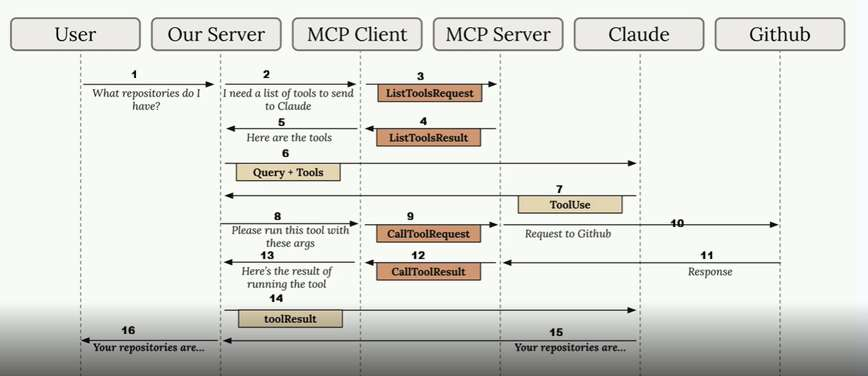

In [6]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/MCP_illustration.png', embed=True))

### <font color="red"><b>Project : CLI based chatbot</b></font>
- We will create a CLI based chatbot
- This will give idea of how MCP client and MCP server actually work together
- This CLI based chatbot will allow users to chat with set of documents -- read document, edit document.
- Users can mention a document by writing out @doc_name -- and the doc contents will be automatically included
- Users can run command in this CLI using "/command_name"<br><br>
**Note :** In a normal project - we will be implementing **either MCP server .. or MCP client - never both**. But in this example project we will do both just for understanding purposes.<br><br>


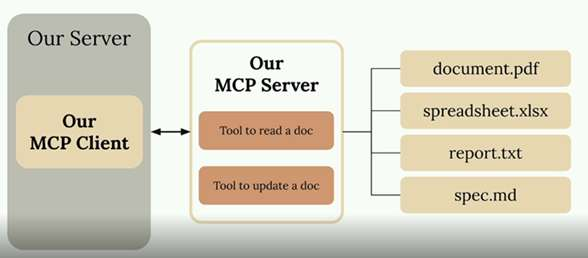

In [8]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/project_cli_based_chatbot.png', embed=True))

All code for this project is in https://github.com/Suvam-Ray/claude_cli_based_chatbot - including detailed commit history
- Look at **commit comment "Updating gitignore to prevent API key from leaking"** - for the initial set of codes
- Look at README.md of this commit version to understand the setup and steps. Open the project folder in IDE like vs code and install dependencies and setup as per the README. Suvam did the following : 
    - Deleted .env file. Comit to stop tracking .env
    - Next added back .env . and added Anthropic API key and set USE_UV = 0 in the .env
    - **`pip install anthropic python-dotenv prompt-toolkit "mcp[cli]==1.8.0"`**
- Open terminal within the project folder ... 
    - run **`uv run main.py`**
    - Or run **`python main.py`** - if you are not using uv
    - Next test this by typing - what is 1 + 1 .... you should get response from LLM that it is 2 .. so your initial setup is ready

#### Adding tools in the MCP server 
- We will now add an MCP server and define 2 tools inside it
    - Tool to read a document
    - Tool to update contents of a document<br><br>
#### Steps :
- In the **commit comment "Stop tracking .env" --> open "mcp_server.py"** -- this has a basic mcp server scaffold
    - It first defines a MCP server object
    - Then it defines list of documents that will exist inside this server
    - Then there are TODO items for the tools, resources and prompts which will be implemented<br><br>
- **Tool schema :** Previously we had to do lot of work to define the tool schema - but in the official MCP SDK - we just have the use the mcp decorator and tool schema will be automatically taken care of.<br><br>
- The above changes for the 2 tools are available in **commit comment "Added 2 tool definitions - read_document and edit_document"**

#### MCP Server Inspector
- We just defined tools inside our mcp server - but we have no idea if it works properly.
- Server inspector is an in-browser debugger which is built-in in the official MCP python SDK. It can be used to inspect the tools defined.
    - Navigate to the project folder. Open terminal.<br><br>
    - Run **`mcp dev mcp_server.py`** --> It will give the url .. open this url in web browser -- **Note :** Open the link which is prefilled with the session token<br><br>
    - After opening the UI -- click on connect --> it will install some packages then the server will start<br><br>
    - In the UI - there are tabs for resources, prompts, tools and many other things ---> click on tools --> click on list tools --> The 2 tools that we defined will appear here.<br><br>
    - Click on read_doc_contents tool --> go to you mcp_server.py -- in this we have defined doc dictionary .. copy any of the key - e.g. "deposition.md" and paste it in the doc_id field in the mcp server ui --> then click run tool --> It will show the content of the tool<br><br>
    - So this shows that the tool is working fine<br><br>
    - Now click on edit document tool --> add doc_id = deposition.md, old_str = This, new_str = A report --> Run tool --> see the updated text ---> see success message but this tool does not return anything --> so go to read document tool --> doc_id = deposition.md --> Run tool --> see the updated message<br><br>
    - Click on disconnect --> ctrl + c on the terminal to close the inspector


#### Defining the client
- We will now create the MCP client

#### Steps :
- In the **commit comment "Added 2 tool definitions - read_document and edit_document"** --> open "mcp_client.py"
    - This just has a single class - "MCP client class"
        - This "MCP client class" wraps "Client session" -- This client session is the actual connection to our MCP server<br><br>
        - The client session is part of the MCP python SDK -- so this is the actual MCP object .. the class is just a custom wrapper that we are using this in this project - can be replaced with something else entirely in future also.<br><br>
        - The session requires a lot of cleanup activities once we close the connection -- and this is what the class is handling today. Look at the connect() , cleanup() , `__aenter__()` , `__aexit__()` functions <br><br>
        - So it is a common practice to not use the client object directly - and instead wrap it in a class which manage all these resources<br><br>
        - The functions list_tools() , call_tools() , list_prompts() , get_prompts() --> these are the functions from this client class which will be called by the rest of the codebase in our solution --- to have client connect to the MCP server and get the details<br><br>
- **Implementing list_tools() functions in client**
    - `result = await self.session().list_tools()` --> This get access to the session i.e. the connection to the MCP server --> then it calls a built-in function list_tools() to get all the tools defined in that MCP server and returns it<br><br>

- **Implementing call_tools() functions in client**
    - `self.session().call_tool(tool_name, tool_input)` --> This get access to the session i.e. the connection to the MCP server --> then it calls a built-in function call_tool() to call a tool with the tool name provided and the input params provided.<br><br>
- The above changes for the 2 tools are available in **commit comment "Added 2 function definitions in MCP client class to list the tools available and to call tool"**



#### Testing the client changes :
- Next to test --> scroll down in the mcp_client.py --> to the main block of the code
    - Code changes were made to this block to make this code testable. see **commit comment "Added 2 function definitions in MCP client class to list the tools available and to call tool"**
        - These changes will start the MCP server -- then it gets the list of all the tools and prints them
    - In terminal run **`python mcp_client.py`**
        - This will generate output like :
        ```
        [Tool(name='read_doc_contents', description='Read the contents of a document and return it as a string.', inputSchema={'properties': {'doc_id': {'description': 'Id of the document to read', 'title': 'Doc Id', 'type': 'string'}}, 'required': ['doc_id'], 'title': 'read_documentArguments', 'type': 'object'}, annotations=None), Tool(name='edit_document', description='Edit a document by replacing a string in the documents content with a new string', inputSchema={'properties': {'doc_id': {'description': 'Id of the document that will be edited', 'title': 'Doc Id', 'type': 'string'}, 'old_str': {'description': 'The text to replace. Must match exactly, including whitespace', 'title': 'Old Str', 'type': 'string'}, 'new_str': {'description': 'The new text to insert in place of the old text', 'title': 'New Str', 'type': 'string'}}, 'required': ['doc_id', 'old_str', 'new_str'], 'title': 'edit_documentArguments', 'type': 'object'}, annotations=None)]
        ```
        


#### Testing CLI chatbot again :
- The chat application in this code base is already calling list_tools() and call_tools() -- and now that we have the definitions updated - we can test the chat application -----> **How the chat app is calling these functions -- you can explore yourself later**<br><br>
- Now with the list tool and call tool functions defined in the client ... the chat application code was already using these tools.
- So lets test this also
- run **`python main.py`** ---> enter "What is content of the report.pdf document?" --> It will respond with the details of the document ---> prompt and output below : 
```
> What is content of the report.pdf document?


Response:
The report.pdf document contains details about the state of a 20m condenser tower.
```

### 40.1.11  b) MCP Components - Resources, Prompts, Tools
- We want users to mention a document by writing out @doc_name -- and the doc contents will be automatically included
- When user do @ -- we want to automatically fetch the list of available documents -- the user can then select a document from the list ... and after that the content of the selected document should be automatically fetched - and inserted in the prompt <br><br>
- So there are 2 aspects : 
    - Upon doing @ -- get list of documents
    - When a prompt contains @doc_name - the content should be automatically fetched and inserted in the prompt<br><br>
- To implement the above 2 features resource are used.<br><br>
- **Resources allow the MCP server to expose data to the client**. In normal operation like get tool list etc -- the data was never exposed to the client - i.e. the end user .. it was always between our server and mcp server or the LLM ... but resource allow that data to be directly exposed to the front end user facing layer.<br><br>
- Resource is similar to GET request handlers in a HTTP servvre ... and it can return any type of data - JSON, string, binary, etc
    - **mime_type** is set to give the client a hint of the datatype<br><br>
- One separate resource is defined for each distinct read operation. So for the above - we will have 2 resource definitions. 




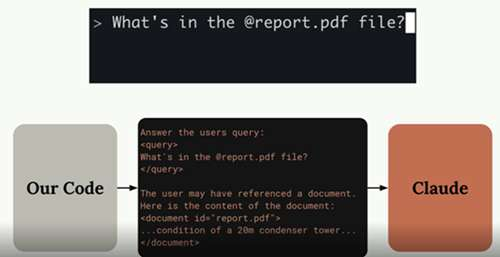

In [9]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/project_cli_based_chatbot_v2.png', embed=True))

#### How communication happens in resource
- The entire flow is as follows<br><br>
- When user types @ --> our code will reach out to MCP client --> which will then send a ReadResourceRequest to MCP Server<br><br>
- Inside the ReadResourceRequest - we will define a URI of the document - **URI is the address of the resource**
    - We construct the URI -- it can be any form of URI -- an s3 uri, a file path uri, a http uri ... anything<br><br>
    - Overall - When the MCP server responsed to a resource request - it will send 3 fields : 
        - uri ---> this is the uri that we construct
        - mimeType --> This is the hit for the return type
        - text --> This is the text output ... can be json or plain text also<br><br>
- After this the MCP server sends the ReadResourceResult to the MCP client and the MCP client sends it to our code and we can do whatever we want with it<br><br>


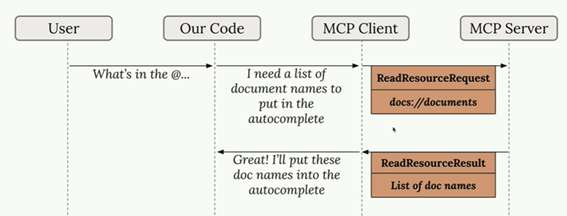

In [10]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/project_cli_based_chatbot_v3.png', embed=True))

#### There are two types of resources
- **Direct Resource**
    - In this the URI does not contain any params -- so the URI is static -- does not change at all ---> this will be used for the @ functionality --- as the list is static
- **Templated Resource**
    - In this the URI contains one or more params -- the python SDK parses these as args to the function ---> this will be used for the document fetching functionality --- as it is specific to the document

#### Steps to add resource definition in MCP server:
- In the **commit comment "Added 2 function definitions in MCP client class to list the tools available and to call tool"** --> open "mcp_server.py"
    - Add resource definition for list_doc ; and fetch_doc
    ```
    @mcp.resource("docs://documents", mime_type="application/json")
    def list_docs() -> list[str]:
        return list(docs.keys())


    @mcp.resource("docs://documents/{doc_id}", mime_type="text/plain")
    def fetch_doc(doc_id: str) -> str:
        if doc_id not in docs:
            raise ValueError(f"Doc with id {doc_id} not found")
        return docs[doc_id]
    ```
    - In list_docs - the final output will havve 3 things : 
        - **uri :** The URI docs://documents is static. Also - since the URI is static - it does not expect any parameter from the client when it is being called - only @ is fine.
        - **mime_type :** The mime_type is just a hit and it mentions that the return type will be a json
        - **text :** Then the function is just sending the list of keys of doc dictionary ... the python SDK will automatically convert this object to a JSON string
        - **output :** In the image below <br><br>
    - In fetch_docs - the final output will havve 3 things : 
        - **uri :** The URI docs://documents/{doc_id} is dynamic. It will expect doc_id parameter from the client when it is being called - after @ . multiple parameter can also be passed - e.g. docs://documents/{doc_id}/{doc_id_2}. All these parameters become part of function signature.
        - **mime_type :** The mime_type is just a hit and it mentions that the return type will be a text
        - **text :** Then the function is just sending the text from the document
        - **output :** In the image below  <br><br>
    - **Testing the changes :**
        - Run MCP server inspector **`mcp dev mcp_server.py`** --> It will give the url .. open this url in web browser -- **Note :** Open the link which is prefilled with the session token
        - After opening the UI -- click on connect --> it will install some packages then the server will start
        - In the UI - go to Resources tab
            - List Resources : This will list the direct resource list_docs  --> click on "docs://documents" --> It will generate output as below with a json list of doc ids
            - List Templates : This will list the template resource fetch_docs --> click on fetch_doc --> enter any doc id - e.g. deposition.md --> read resource --> It will generate the output as below
        - Disconnect in the UI --> Close the mcp server inspecter in terminal with ctrl + c<br><br>

    - Commit comment : **"Added 2 resource definitions in MCP server code to list documents when @ is typed and to get document content for the document specified in @doc_id "**

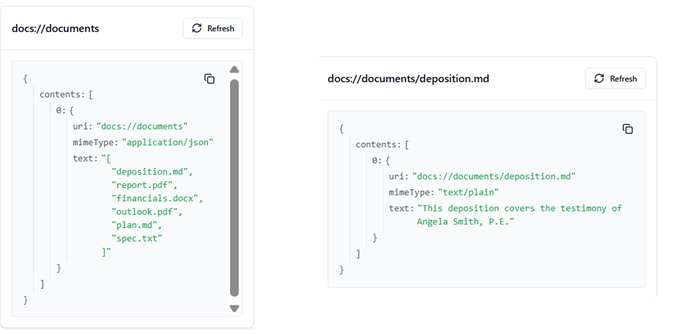

In [11]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/project_cli_based_chatbot_v4.png', embed=True))

#### Steps to add function in MCP client to call resource defined in the MCP server:
- In the **commit comment "Added 2 resource definitions in MCP server code to list documents when @ is typed and to get document content for the document specified in @doc_id "** --> open "mcp_client.py"
    - Add read_resource definition
    ```
    async def read_resource(self, uri: str) -> Any:
        result = await self.session().read_resource(AnyUrl(uri))
        resource = result.contents[0]

        if isinstance(resource, types.TextResourceContents):
            if resource.mimeType == "application/json":
                return json.loads(resource.text)

            return resource.text
    ```
    - In read_resource - we have updated the following : 
        - `result = await self.session().read_resource(AnyUrl(uri))` --> This gets access to the session i.e. the connection to the MCP server --> then it calls a built-in function read_resource() using the uri to call the resource having that URI 
        - Next if the see above in the above -- `contents[0]` is what we want to extract from the output -- so that is extracted ... 
        - Next it is checked if `content[0]` is of text type ... and if mimeType is application/json -- then we parse the json from "text" field and return ... else we return the "text" field as it is<br><br>

    - Commit comment : **"Updated mcp_client.py to call resources defined in mcp_server.py -- read_resource"**
    
    - The chat application in this code base is already calling read_resource() -- and now that we have the definitions updated - we can test the chat application -----> **How the chat app is calling these functions -- you can explore yourself later**<br><br>
    - run **`python main.py`** ---> enter "What its in @" --> You will see dropdown with list of document --> use down arrow to select and press space --> What its in @report.pdf document --> Claude will respond -- notice that claude did not have to use read tool --> Prompt and response below ----- in the earlier eaxmple of "What is content of the report.pdf document?" -- there was a list tool then call tool that claude did ... but here claude was already provided the content using the resource
    ```
    > Whats in @report.pdf document ?

    Response:
    The report.pdf document contains details about the state of a 20m condenser tower.
    ```



#### Prompts in MCP Server
- Prompts are more like shortcuts to prompts that you can define in the MCP server -- and from the chat application you can use "/`<prompt_shortcut_name>` `<space>` `<doc_id>`" to access it.<br><br>
- so typing `/` will list all available list of prompts ... and when a prompt is selected e.g. `/format` -- then list of all document_ids will appear in chat (through list_docs resource) ... and upon selecting the document -- we will insert the content of the document (through fetch_docs resource) -- and the prompt corresponding to `/format` will be inserted and then sent to claude. <br><br>
- The `/format` prompt that we will design here - it should have a prompt to format the file in a nice markdown format<br><br>
- In theory -- this request for fomatting a document can very easily achieved by the user -- by him providing the prompt to format directly -- but there will be cases where we want to templatize certain prompt, use prompt engineering techniques, eval the prompt and make it available to all users -- this is where this feature is very helpful<br><br>


#### Steps to add prompt in MCP server:
- In the **commit comment "Updated mcp_client.py to call resources defined in mcp_server.py -- read_resource"** --> open "mcp_server.py"
    - Add format_document definition
    ```
    @mcp.prompt(
        name="format",
        description="Rewrites the contents of the document in Markdown format.",
    )
    def format_document(
        doc_id: str = Field(description="Id of the document to format"),
    ) -> list[base.Message]:
        prompt = f"""
        Your goal is to reformat a document to be written with markdown syntax.

        The id of the document you need to reformat is:
        <document_id>
        {doc_id}
        </document_id>

        Add in headers, bullet points, tables, etc as necessary. Feel free to add in extra text, but don't change the meaning of the report.
        Use the 'edit_document' tool to edit the document. After the document has been edited, respond with the final version of the doc. Don't explain your changes.
        """

        return [base.UserMessage(prompt)]
    ```
    - In format_document - we have updated the following : 
        - This prompt requires a doc_id parameter -- the same is present in the funciton signature
        - Next we have the prompt -- which uses prompt engineering technique like markup -- and in this prompt we are also instructing claude to use the edit_document tool to edit the document .. and not to explain changes ... such prompt engineering might not be possible for users to give.
        - Next we return the updated prompt as the updated "UserMessage" -- so claude will read this as the user message<br><br>

    - Commit comment : **"Updated mcp_server.py to define prompt  -- format_document"**<br><br>
    
    - Next open MCP server inspector `mcp dev mcp_server.py` --> open url which has the token --> connect
        - Go to prompts tab --> List Prompts
        - Select "format" --> Enter "report.pdf" as doc_id --> Get prompt --> output below :<br><br>


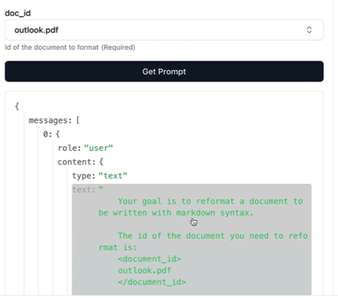

In [12]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/project_cli_based_chatbot_v5.png', embed=True))

#### Steps to add functions in MCP client to list prompt and to call prompts defined in MCP server:
- In the **commit comment "Updated mcp_server.py to define prompt  -- format_document -- read_resource"** --> open "mcp_server.py"
    - Add list_prompts and get_prompt definition
    ```
    async def list_prompts(self) -> list[types.Prompt]:
        result = await self.session().list_prompts()
        return result.prompts

    async def get_prompt(self, prompt_name, args: dict[str, str]):
        result = await self.session().get_prompt(prompt_name, args)
        return result.messages
    ```
    - In the above - we have updated the following : 
        - `await self.session()` -- loads session object ... and then we call inbuilt list_prompts and get_prompt functions.. These are inbuult functions of the MCP SDK
        - get_prompt also expects an argument dictionary -- which will be sent to the prompt function -- i.e. doc_id in our case.<br><br>

    - Commit comment : **"Updated mcp_client.py to define list_prompts and get_prompt"**<br><br>
    
    - The chat application in this code base is already calling list_prompts() and get_prompt() -- and now that we have the definitions updated - we can test the chat application -----> **How the chat app is calling these functions -- you can explore yourself later**<br><br>
    - **Note :** In the chat application ... after typing `/format <space>` the list of doc_ids come automatically -- this is a resource fetch implementation that was done in the chat application -- it was not covered in the steps above -- but the code can be evaluated and understood if needed. <br><br>
    - **Also Note :** Here in the prompt function in the mcp server -- the prompt is just inserting the doc_id .. and then claude has to do a tool call to read the document .. and then work on it ... instead - we can implement a resource call to insert the document content in the prompt directly once doc_id is provided ... this can be taken up later if needed.<br><br>
    - run **`python main.py`** ---> enter "`/format <space>`" --> You will see dropdown with list of document select plan.md--> claude will then use read tool to read the document and then convert to markdown
    ```
    > /format plan.md
    I'll help you reformat the document with markdown syntax. Let me first read the document to see its current content.
    Now I'll reformat this document with proper markdown syntax, adding headers and structure:


    Response:
    # Project Implementation Plan

    ## Overview

    This plan outlines the steps for the project's implementation.
    ```



#### Overall in the Project : CLI based chatbot
- <font color="red"><b>The actual code for CLI client was not discussed - and the CLI client already was calling MCP client functions for tools, prompts and resources defined in MCP server --- what we did was to only define the functions for the tools, prompts and resources in mcp server code -- and update the mcp client code to call those functions</b></font><br><br>
- <font color="red"><b>That is all that was done</b></font><br><br>
- <font color="red"><b>If detailed understanding of the actual CLI client is needed - then explore the codebase yourself</b></font>

## 40.1.12) Advanced MCP

### 40.1.12  a) MCP Advanced - Sampling
- Sampling allows a MCP server to access an LLM through a connected MCP client.<br><br>
- Consider a scenario where you make some request for doing some research -- now there is a research tool which will go to wikipedia - pull content from 2-3 pages - and when the tool itself wants to do an LLM call to summarize the finding before handing over to LLM on the client.
- Now - to do the above - we would need to setup an API within the MCP server - and then it will be able to do an LLM call -- however - this is dangerous - as if this is a publicly available MCP server - then effectively you are offering free LLM calls inside your MCP server<br><br>
- **So the general practice is to not have LLM calls inside MCP server** - instead - when the MCP server needs an LLM call -- it will send a **Sampling request** to the client - and client will call the LLM on behalf of the MCP server and give the result back to MCP server. With this - the API or LLM setup already available in MCP client is leveraged - and it helps with not exposing a free LLM call within MCP server to the world<br><br>
- So for regular communication -- MCP clients calls server and gets a response ( tool output ) -- but in sampling -- MCP server does calls the client and gets a response.<br><br>
- **Illustration below :**


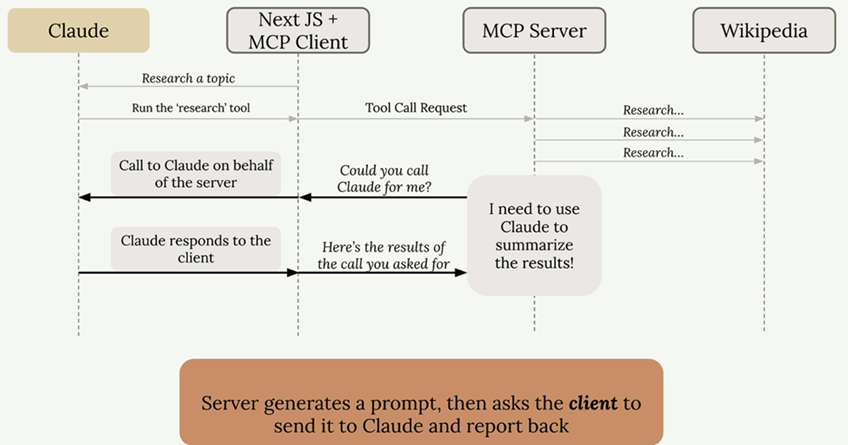

In [25]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_sampling.png', embed=True))

### **How to implement sampling :**
- Sampling requires setup on both the MCP server tool function and the MCP client also.<br><br>
- **In MCP Server :** 2 changes : 
    - Add context object ctx ( from MCP SDK ) in function signature of the tool.
    - In the tool function definition --  request an LLM call using "create_message()" function on context<br><br>
- **In MCP client :** 3 changes : 
    - Implement a sampling_callback() function which recieves this request from server and does the LLM call. Note that the sampling_callback() function in client is applying a parsing function chat() on the text recieved from MCP server param.
    - Implement a chat() function - to extract information from the parameter sent by MCP server. The parameter from MCP server will be in MCP format -- not in chat compatible format -- so it needs to be parsed / processed.
    - When defining the client object - pass the sampling callback function definition -- so that the client knows that it can expect a callback from server.<br><br>
- **MCP Server - #1 and #2 : create_message() call inside tool definition of MCP server - summarize() is the tool**
```
@mcp.tool()
async def summarize(text_to_summarize: str, ctx: Context):
    prompt = f"""
    Please summarize the following text:
    {text_to_summarize}
    """
    
    result = await ctx.session.create_message(
        messages=[
            SamplingMessage(
                role="user",
                content=TextContent(
                    type="text",
                    text=prompt
                )
            )
        ],
        max_tokens=4000,
        system_prompt="You are a helpful research assistant",
    )
    
    if result.content.type == "text":
        return result.content.text
    else:
        raise ValueError("Sampling failed")
```
<br><br>
- **MCP client #1 : Define sampling_callback() in MCP client**
```
async def sampling_callback(
    context: RequestContext, params: CreateMessageRequestParams
):
    # Call Claude using the Anthropic SDK
    text = await chat(params.messages)
    
    return CreateMessageResult(
        role="assistant",
        model=model,
        content=TextContent(type="text", text=text),
    )
```
<br><br>
- **MCP client #2 : Define parsing function chat() to parse infor from MCP server parameter**
```
async def chat(input_messages: list[SamplingMessage], max_tokens=4000):
    messages = []
    for msg in input_messages:
        if msg.role == "user" and msg.content.type == "text":
            content = (
                msg.content.text
                if hasattr(msg.content, "text")
                else str(msg.content)
            )
            messages.append({"role": "user", "content": content})
        elif msg.role == "assistant" and msg.content.type == "text":
            content = (
                msg.content.text
                if hasattr(msg.content, "text")
                else str(msg.content)
            )
            messages.append({"role": "assistant", "content": content})

    response = await anthropic_client.messages.create(
        model=model,
        messages=messages,
        max_tokens=max_tokens,
    )

    text = "".join([p.text for p in response.content if p.type == "text"])
    return text
```

**`chat()` Function: Flow**
* **Reformatting:** Converts MCP `SamplingMessage` objects into the simple dictionary format (`role` and `content`) required by the Anthropic SDK.
* **Role Mapping:** Identifies and labels **user** vs. **assistant** messages to maintain conversation history.
* **Extraction:** Safely pulls plain text from MCP content blocks, using `str()` as a fallback to prevent errors.
* **Execution:** Sends the cleaned messages to Claude and returns the response as a single, joined string.

<br><br>
- **MCP client #3 : Pass the sampling callback when initializing the client session in MCP client**
```
async with ClientSession(
    read,
    write,
    sampling_callback=sampling_callback
) as session:
    await session.initialize()
```

#### Implementation changes in context of current code
In the current code - "mcp_client.py" of https://github.com/Suvam-Ray/claude_cli_based_chatbot - We have the following line in connect() definition. This is where the client connection is being defined.
```
self._session = await self._exit_stack.enter_async_context(
    ClientSession(_stdio, _write))
```
<br><br>
To enable sampling callback - we need to define the sampling_callback function , and chat() function in the client class as above .. and then update the client session as below : 
```
self._session = await self._exit_stack.enter_async_context(
    ClientSession(_stdio, _write, sampling_callback=self.sampling_callback))
```
<br><br>
For - "mcp_server.py" of https://github.com/Suvam-Ray/claude_cli_based_chatbot - We have to update the tool function definition to include ctx in the parameter .. and do a sampling callback function call -- as illustrated above. 

#### Understanding of the ctx parameter - defined in the MCP tool function signature.
- The `ctx` object (short for **Context**) is an object automatically injected by the **MCP SDK** when a client calls a tool. It represents the "connection" or "session" between that specific client and the server.<br><br>
- **Where does `ctx` come from?**
    - You don't need to create or pass this object yourself from the client tool call. When you define a tool using the `@mcp.tool()` decorator, the MCP framework is designed to look at the function signature. If it sees `ctx: Context`, it **automatically provides** the active session object to that function at runtime.<br><br>
- **The full Trail (including the "ctx" Lifecycle) - to understand how everything is working**
    1.  **MCP Client $\rightarrow$ Tool Call:** The client sends a request to run the `summarize` tool. The MCP client does not need to pass any ctx parameter explicitly.
    2.  **Server $\rightarrow$ SDK Handling:** The MCP Server receives the request. The SDK identifies that `summarize` needs a `Context` object. 
    3.  **SDK $\rightarrow$ `ctx` Injection:** The SDK creates the `ctx` object, which contains a reference to the **`session`** (the bridge back to the client that just called it).
    4.  **Tool Execution:** The `summarize(text, ctx)` function runs. 
        * When you call `await ctx.session.create_message(...)`, you are essentially sending a message **back up the same pipe** the client used to call the tool.
    5.  **Sampling Callback:** The client receives this "sampling request," performs the LLM call, and sends the text back to the server.
    6.  **Tool Completion:** The server (inside the `summarize` tool) receives that text, finishes its logic, and returns the final result to the client.

### 40.1.12  b) MCP Advanced - Logs and Progress Tracking
- Without log and progress notification - we do not get any feedback if the MCP tool call is progressing - or has failed.
- Below is an example - where there is a progress bar -- and log statements being printed. These allow for better user experience.<br><br>
- Changes have to be made in MCP client and server to enable exchange of these logs and notifications --- and then the client can render UI component - to display a progress bar on the UI and to print the logs nicely in the UI. The rendering part is not covered in this section - we will only do print statements here -- but it can be easily extended to a UI component later - as a separate personal project later it needed.


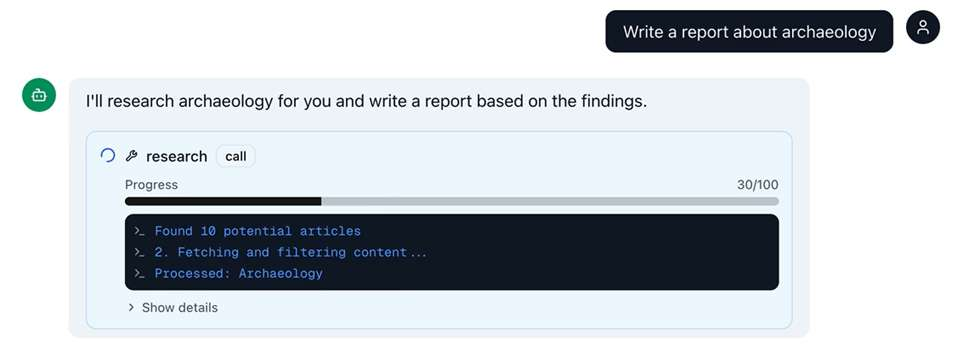

In [26]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/mcp_logging_notification.png', embed=True))

### **How to implement logging and progress notification :**
- Requires setup on both the MCP server tool function and the MCP client also.<br><br>
- **In MCP Server :** 2 changes : 
    - Add context object ctx ( from MCP SDK ) in function signature of the tool.
    - In the tool function definition --  call ctx.info() to send log messages to the client .. and call ctx.report_progress to report progress to the client.<br><br>
- **In MCP client :** 4 changes : 
    - Implement a logging_callback() function which recieves information sent in context.info() call from server.
    - Implement a print_progress_callback() function which recieves information sent in context.report_progress() call from server.
    - When defining the client object - pass the logging_callback function  -- so that the client knows that it can expect a callback from server.
    - When doing call_tool() inside the client -- then pass print_progress_callback() <br><br>
- **MCP Server - #1 and #2 : ctx.info() and ctx.report_progress() call inside tool definition of MCP server - tool() is the tool**
```
@mcp.tool()
async def add(a: int, b: int, ctx: Context) -> int:
    await ctx.info("Preparing to add...")
    await ctx.report_progress(20, 100)

    await asyncio.sleep(2)

    await ctx.info("OK, adding...")
    await ctx.report_progress(80, 100)

    return a + b
```
<br><br>
- **MCP client #1 and #2 : Define logging_callback() and print_progress_callback() in MCP client**. Here we are just printing the output - but we can also push these to the UI components and render these in the UI also.
```
async def logging_callback(params: LoggingMessageNotificationParams):
    print(params.data)


async def print_progress_callback(
    progress: float, total: float | None, message: str | None
):
    if total is not None:
        percentage = (progress / total) * 100
        print(f"Progress: {progress}/{total} ({percentage:.1f}%)")
    else:
        print(f"Progress: {progress}")
```
<br><br>
- **MCP client #3 and #4 : When defining the client object - pass the logging_callback function. When doing call_tool() inside the client -- then pass print_progress_callback()**
```
async def run():
    async with stdio_client(server_params) as (read, write):
        async with ClientSession(
            read, write, logging_callback=logging_callback
        ) as session:
            await session.initialize()

            await session.call_tool(
                name="add",
                arguments={"a": 1, "b": 3},
                progress_callback=print_progress_callback,
            )
```

#### Implementation changes in context of current code
In the current code - "mcp_client.py" of https://github.com/Suvam-Ray/claude_cli_based_chatbot - We have the following line in connect() definition. This is where the client connection is being defined.
```
self._session = await self._exit_stack.enter_async_context(
    ClientSession(_stdio, _write))
```
<br><br>
To enable logging - we need to define the logging_callback function, in the client class as above .. and then update the client session as below : 
```
self._session = await self._exit_stack.enter_async_context(
    ClientSession(_stdio, _write, logging_callback=self.logging_callback))
```
<br><br><br><br><br><br>
In the current code - "mcp_client.py" of https://github.com/Suvam-Ray/claude_cli_based_chatbot - We have the following line in call_tool() definition.
```
async def call_tool(
    self, tool_name: str, tool_input
) -> types.CallToolResult | None:
    return await self.session().call_tool(tool_name, tool_input)
```
<br><br>
To enable progress_callback - we need to define the print_progress_callback function, in the client class as above .. and then update the call_tool as below : 
```
async def call_tool(
    self, tool_name: str, tool_input
) -> types.CallToolResult | None:
    return await self.session().call_tool(
        tool_name, 
        tool_input, 
        progress_callback=self.print_progress_callback
    )
```
<br><br><br><br>
For - "mcp_server.py" of https://github.com/Suvam-Ray/claude_cli_based_chatbot - We have to update the tool function definition to include ctx in the parameter .. and do a  ctx.info() to send log messages to the client .. and call ctx.report_progress  function call -- as illustrated above. 

### 40.1.12  c) MCP Advanced - Roots
- Roots are a way to grant MCP servers access to specific files and folders on your local machine. 
- Think of them as a permission system that says "Hey, MCP server, you can access these files"<br><br>
- Since this did not sound very relevant - notes were skipped for this. Later MCP documentation can be reffered to if Roots functionality is needed. 



---

[➡ <font color="red"><b>Continue to Part 2b — MCP Transport, Claude Code & Agents</b></font>](part2b_advncd_mcp_claude_code_agents.ipynb)
